# AIR QUALITY PREDICTION CLASSIFICATION MODELS


## SVM (Support Vector Machine)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

Accuracy: 98.65%


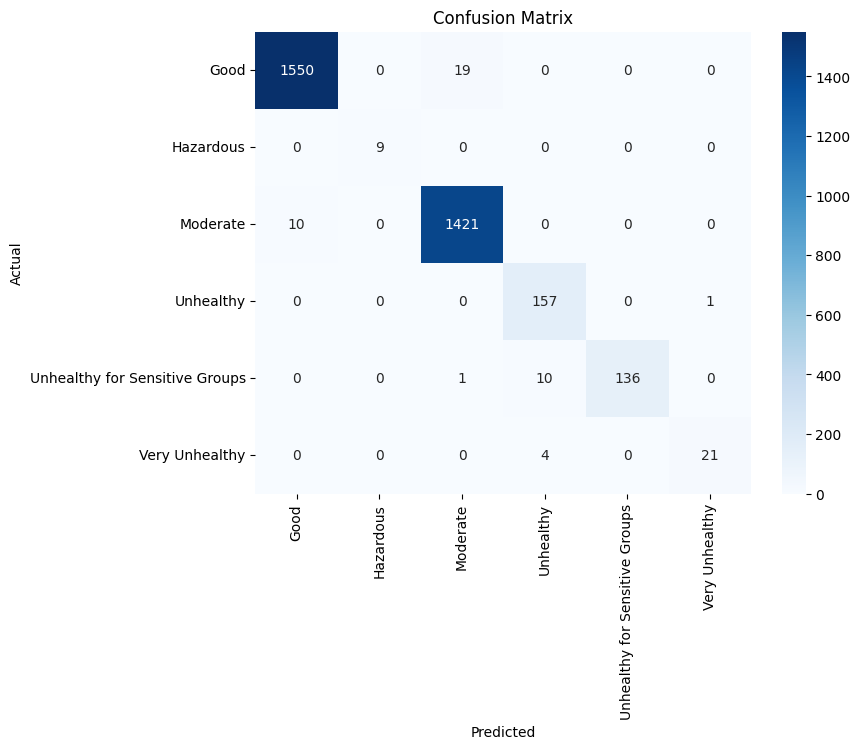

Classification Report:
                                precision    recall  f1-score   support

                          Good       0.99      0.99      0.99      1569
                     Hazardous       1.00      1.00      1.00         9
                      Moderate       0.99      0.99      0.99      1431
                     Unhealthy       0.92      0.99      0.95       158
Unhealthy for Sensitive Groups       1.00      0.93      0.96       147
                Very Unhealthy       0.95      0.84      0.89        25

                      accuracy                           0.99      3339
                     macro avg       0.98      0.96      0.96      3339
                  weighted avg       0.99      0.99      0.99      3339



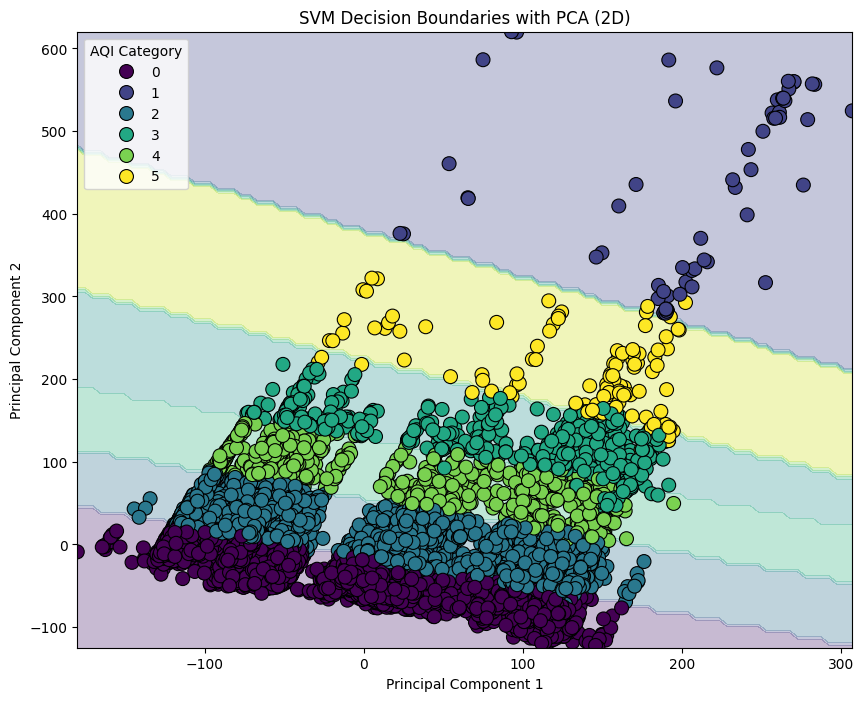

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

# Load your dataset (replace 'file_path' with your actual file path)
df = pd.read_csv('D:\Air-Quality-Prediction\Data\Real-Data\AQI and Lat Long of Countries.csv')

# Preprocessing: handle missing values if any
df = df.dropna()  # or use df.fillna() depending on your need

# Encode categorical columns ('AQI Category', 'CO AQI Category', etc.)
label_encoders = {}
categorical_columns = ['AQI Category', 'CO AQI Category', 'Ozone AQI Category', 
                       'NO2 AQI Category', 'PM2.5 AQI Category']  # Add more columns if necessary
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Selecting features and target
X = df[['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value', 'lat', 'lng']]
y = df['AQI Category']  # Assuming 'AQI Category' is the target you want to predict

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the SVM model
svm = SVC(kernel='linear')  # You can use other kernels like 'rbf', 'poly' depending on your data
svm.fit(X_train, y_train)

# Predict on the test set
y_pred = svm.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoders['AQI Category'].classes_, yticklabels=label_encoders['AQI Category'].classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=label_encoders['AQI Category'].classes_))

# If you want to visualize the decision boundaries, use PCA to reduce dimensions to 2D
# This is only feasible for 2 features or a PCA reduction to 2 features
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Train the model again with the PCA features for visualization
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)
svm.fit(X_train_pca, y_train_pca)

# Plot decision boundaries
xx, yy = np.meshgrid(np.linspace(X_pca[:, 0].min(), X_pca[:, 0].max(), 100),
                     np.linspace(X_pca[:, 1].min(), X_pca[:, 1].max(), 100))
Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis', marker='o', s=100, edgecolor='k')
plt.title('SVM Decision Boundaries with PCA (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


## K-NN

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1569
           1       0.86      0.67      0.75         9
           2       0.93      0.95      0.94      1431
           3       0.87      0.95      0.91       158
           4       0.90      0.76      0.82       147
           5       0.75      0.72      0.73        25

    accuracy                           0.94      3339
   macro avg       0.88      0.83      0.85      3339
weighted avg       0.94      0.94      0.93      3339

Confusion Matrix:


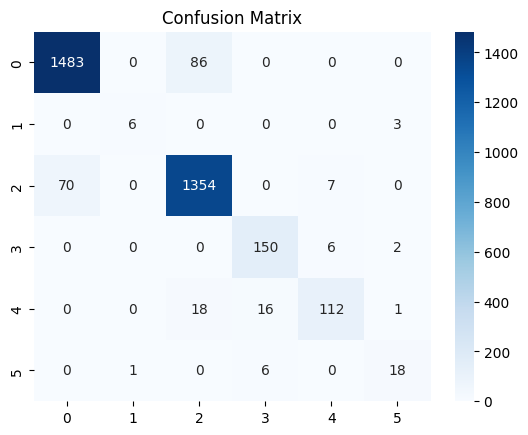

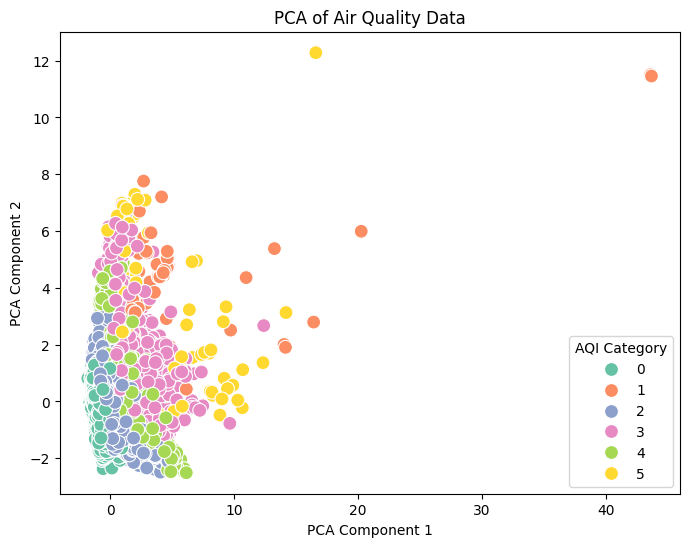

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# Load the dataset
# Assuming your dataset is in a CSV file named 'air_quality_data.csv'
df = pd.read_csv('Data\Real-Data\AQI and Lat Long of Countries.csv')

# Data Preprocessing
# Drop rows with missing values (if any)
df = df.dropna()

# Encode categorical variables (AQI Categories)
label_encoders = {}
categorical_columns = ['AQI Category', 'CO AQI Category', 'Ozone AQI Category', 'NO2 AQI Category', 'PM2.5 AQI Category']

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Save the label encoder for potential reverse transformation

# Features and Target
# Assuming we are predicting the AQI Category (you can change the target as needed)
X = df[['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value', 'lat', 'lng']]
y = df['AQI Category']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Normalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can tune the value of k
knn.fit(X_train_scaled, y_train)

# Predictions
y_pred = knn.predict(X_test_scaled)

# Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Visualizing the data using PCA for dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train, palette="Set2", s=100)
plt.title("PCA of Air Quality Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="AQI Category")
plt.show()


## Multi Layer Perceptron

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1569
           1       0.82      1.00      0.90         9
           2       1.00      1.00      1.00      1431
           3       0.95      0.99      0.97       158
           4       0.99      0.95      0.97       147
           5       0.95      0.84      0.89        25

    accuracy                           0.99      3339
   macro avg       0.95      0.96      0.95      3339
weighted avg       0.99      0.99      0.99      3339

Confusion Matrix:


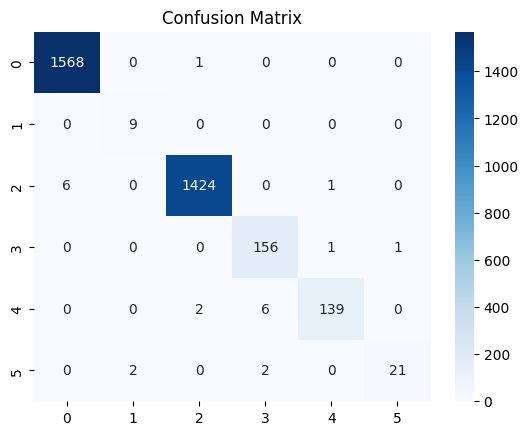

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv('Data\Real-Data\AQI and Lat Long of Countries.csv')

# Data Preprocessing
df = df.dropna()

# Encode categorical variables (AQI Categories)
label_encoders = {}
categorical_columns = ['AQI Category', 'CO AQI Category', 'Ozone AQI Category', 'NO2 AQI Category', 'PM2.5 AQI Category']

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Features and Target
X = df[['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value', 'lat', 'lng']]
y = df['AQI Category']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Normalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Multi-Layer Perceptron Classifier
mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)

# Predictions
y_pred = mlp.predict(X_test_scaled)

# Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


## Naive Bayes using Gaussian Distribution

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      1569
           1       1.00      0.78      0.88         9
           2       0.90      0.79      0.84      1431
           3       0.85      0.89      0.87       158
           4       0.65      0.78      0.71       147
           5       0.68      0.76      0.72        25

    accuracy                           0.86      3339
   macro avg       0.82      0.82      0.82      3339
weighted avg       0.86      0.86      0.86      3339

Confusion Matrix:


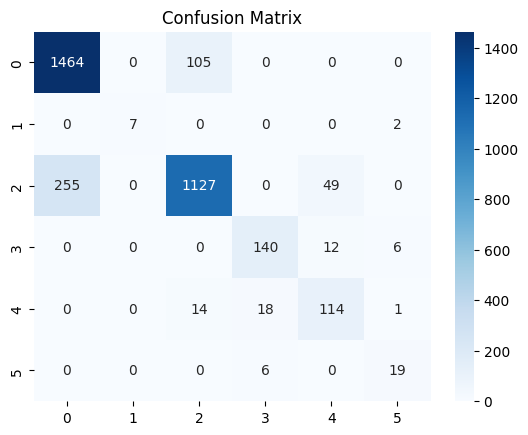

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv('Data\Real-Data\AQI and Lat Long of Countries.csv')

# Data Preprocessing
df = df.dropna()

# Encode categorical variables (AQI Categories)
label_encoders = {}
categorical_columns = ['AQI Category', 'CO AQI Category', 'Ozone AQI Category', 'NO2 AQI Category', 'PM2.5 AQI Category']

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Features and Target
X = df[['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value', 'lat', 'lng']]
y = df['AQI Category']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Normalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Naive Bayes Classifier
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

# Predictions
y_pred = nb.predict(X_test_scaled)

# Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
